In [2]:
import math
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import yfinance as yf
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset

from model import LSTMForecaster
from transformer_model import TimeSeriesTransformer


In [3]:
# ── Data ──────────────────────────────────────────────────────────────────────
TICKER = "AAPL"
PERIOD = "3y"
INTERVAL = "1d"
MIN_ROWS_DOWNLOAD = 20

# ── Train / val / test split ──────────────────────────────────────────────────
TRAIN_FRAC   = 0.70
VAL_END_FRAC = 0.85   # test is remainder

# ── Sequence windows ──────────────────────────────────────────────────────────
LOOKBACK   = 20
HORIZON    = 1
BATCH_SIZE = 32

# ── Volatility features ───────────────────────────────────────────────────────
USE_VOL_FEATURES = False
NUM_VOL_FEATURES = 2       # atr_pct + rv_ewm; counted only when USE_VOL_FEATURES
ATR_EWM_SPAN     = 14
RV_EWM_SPAN      = 19

INPUT_DIM = 5 + (NUM_VOL_FEATURES if USE_VOL_FEATURES else 0)

# ── Transformer architecture ──────────────────────────────────────────────────
TF_D_MODEL           = 32
TF_NHEAD             = 2
TF_NUM_LAYERS        = 2
TF_DROPOUT           = 0.127
TF_DIM_FEEDFORWARD   = 256
TF_POS_ENCODING_MAX_LEN = 5000

# ── LSTM architecture ─────────────────────────────────────────────────────────
LSTM_HIDDEN_SIZE = 64
LSTM_NUM_LAYERS  = 2
LSTM_DROPOUT     = 0.2

# ── Training ──────────────────────────────────────────────────────────────────
NUM_EPOCHS         = 200
LEARNING_RATE      = 0.002326
WEIGHT_DECAY       = 0.0001357
SCHEDULER_PATIENCE = 10
SCHEDULER_FACTOR   = 0.5
SCHEDULER_MIN_LR   = 1e-6
LOG_EVERY          = 20

# ── StockReturnLoss weights ───────────────────────────────────────────────────
VAR_WEIGHT  = 1.654
DIR_WEIGHT  = 0.566
HINGE_SCALE = 0.440

# ── Optuna ────────────────────────────────────────────────────────────────────
OPTUNA_N_TRIALS        = 30
OPTUNA_EPOCHS_PER_TRIAL = 100
OPTUNA_SEED            = 42
OPTUNA_OBJECTIVE       = "val_directional_accuracy"  # "val_loss" | "val_directional_accuracy"

# ── Plotting ──────────────────────────────────────────────────────────────────
SAMPLE_IDX = 5   # index into test set for single-sample price forecast plot


In [4]:
DEFAULT_FEATURE_COLUMNS = ["open", "high", "low", "close", "volume"]


def download_stock_data(
    ticker: str = "AAPL",
    period: str = "3y",
    interval: str = "1d",
) -> pd.DataFrame:
    """Download OHLCV data and return a clean lowercase-column DataFrame."""
    data = yf.download(ticker, period=period, interval=interval, auto_adjust=True, progress=False)
    if data.empty:
        raise ValueError(f"No data returned for ticker={ticker!r}.")

    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)

    data = data.rename(columns={"Open": "open", "High": "high", "Low": "low",
                                 "Close": "close", "Volume": "volume"})
    cleaned = data[DEFAULT_FEATURE_COLUMNS].dropna().reset_index(drop=True)

    if len(cleaned) <= MIN_ROWS_DOWNLOAD:
        raise ValueError("Downloaded dataset is too small.")
    return cleaned


In [5]:
class StockSequenceDataset(Dataset):
    """Dataset of sliding-window features and multi-step targets."""

    def __init__(self, X: np.ndarray, y: np.ndarray) -> None:
        self.X = torch.as_tensor(X, dtype=torch.float32)
        self.y = torch.as_tensor(y, dtype=torch.float32)

    def __len__(self) -> int:
        return len(self.X)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        return self.X[idx], self.y[idx]


def create_sequences(
    X: np.ndarray, y: np.ndarray, lookback: int, horizon: int
) -> Tuple[np.ndarray, np.ndarray]:
    """Convert flat arrays into sliding windows."""
    X_seq, y_seq = [], []
    for end_idx in range(lookback, len(X) - horizon + 1):
        X_seq.append(X[end_idx - lookback : end_idx])
        y_seq.append(y[end_idx : end_idx + horizon].reshape(-1))
    return np.asarray(X_seq, dtype=np.float32), np.asarray(y_seq, dtype=np.float32)


VOL_FEATURES = ("atr_pct", "rv_ewm")


def compute_returns(
    df: pd.DataFrame,
    use_vol: bool = None,
    atr_ewm_span: int = None,
    rv_ewm_span: int = None,
) -> pd.DataFrame:
    """Convert raw OHLCV into percent-return features; optionally add volatility columns."""
    if use_vol is None:
        use_vol = USE_VOL_FEATURES
    atr_span = ATR_EWM_SPAN if atr_ewm_span is None else atr_ewm_span
    rv_span  = RV_EWM_SPAN  if rv_ewm_span  is None else rv_ewm_span

    out = df[["open", "high", "low", "close", "volume"]].pct_change().copy()
    out.columns = ["open_ret", "high_ret", "low_ret", "close_ret", "volume_ret"]

    if use_vol:
        prev_close = df["close"].shift(1)
        tr = pd.concat(
            [df["high"] - df["low"],
             (df["high"] - prev_close).abs(),
             (df["low"]  - prev_close).abs()],
            axis=1,
        ).max(axis=1)
        out["atr_pct"] = (tr / prev_close).ewm(span=atr_span, adjust=False).mean()
        out["rv_ewm"]  = out["close_ret"].ewm(span=rv_span, adjust=False).std()

    return out.dropna()


def prepare_datasets(
    df: pd.DataFrame,
    feature_columns: List[str] = None,
    target_column: str = "close_ret",
    lookback: int = 20,
    horizon: int = 1,
    batch_size: int = 32,
    use_vol_features: bool = None,
    atr_ewm_span: int = None,
    rv_ewm_span: int = None,
) -> Dict:
    """Full pipeline from raw OHLCV DataFrame to DataLoaders using percent-return features."""
    use_vol    = USE_VOL_FEATURES if use_vol_features is None else use_vol_features
    returns_df = compute_returns(df, use_vol=use_vol,
                                 atr_ewm_span=atr_ewm_span, rv_ewm_span=rv_ewm_span)

    base_feats     = ["open_ret", "high_ret", "low_ret", "close_ret", "volume_ret"]
    feature_columns = feature_columns or (
        base_feats + list(VOL_FEATURES) if use_vol else base_feats
    )
    returns_df = returns_df.dropna().copy()

    n         = len(returns_df)
    train_end = int(n * TRAIN_FRAC)
    val_end   = int(n * VAL_END_FRAC)

    train_df = returns_df.iloc[:train_end].copy()
    val_df   = returns_df.iloc[train_end - lookback : val_end].copy()
    test_df  = returns_df.iloc[val_end  - lookback :].copy()

    # Z-score vol features on train statistics only (avoid leakage)
    if use_vol:
        for c in VOL_FEATURES:
            mu  = train_df[c].mean()
            sig = train_df[c].std() + 1e-8
            train_df[c] = (train_df[c] - mu) / sig
            val_df[c]   = (val_df[c]   - mu) / sig
            test_df[c]  = (test_df[c]  - mu) / sig

    def _transform(df_part):
        X = df_part[feature_columns].values.astype(np.float32)
        y = df_part[[target_column]].values.astype(np.float32)
        return create_sequences(X, y, lookback, horizon)

    train_X, train_y = _transform(train_df)
    val_X,   val_y   = _transform(val_df)
    test_X,  test_y  = _transform(test_df)

    dataloaders = {
        "train": DataLoader(StockSequenceDataset(train_X, train_y),
                            batch_size=batch_size, shuffle=False,
                            drop_last=True, num_workers=0),
        "val":   DataLoader(StockSequenceDataset(val_X, val_y),
                            batch_size=batch_size, shuffle=False),
        "test":  DataLoader(StockSequenceDataset(test_X, test_y),
                            batch_size=batch_size, shuffle=False),
    }

    return {
        "dataloaders": dataloaders,
        "train_df":    train_df,
        "val_df":      val_df,
        "test_df":     test_df,
        "returns_df":  returns_df,
    }


In [6]:
df = download_stock_data(ticker=TICKER, period=PERIOD, interval=INTERVAL)
print(f"Downloaded {len(df)} rows for {TICKER}  ({PERIOD} @ {INTERVAL})")

prepared = prepare_datasets(
    df,
    lookback=LOOKBACK,
    horizon=HORIZON,
    batch_size=BATCH_SIZE,
)

train_loader = prepared["dataloaders"]["train"]
val_loader   = prepared["dataloaders"]["val"]
test_loader  = prepared["dataloaders"]["test"]

print(f"Train batches : {len(train_loader)}  ({len(train_loader.dataset)} samples)")
print(f"Val   batches : {len(val_loader)}  ({len(val_loader.dataset)} samples)")
print(f"Test  batches : {len(test_loader)}  ({len(test_loader.dataset)} samples)")

batch_X, batch_y = next(iter(train_loader))
print(f"\nX shape: {batch_X.shape}  |  y shape: {batch_y.shape}")
print(f"X mean/std: {batch_X.mean():.4f} / {batch_X.std():.4f}")
print(f"y mean/std: {batch_y.mean():.4f} / {batch_y.std():.4f}")


Downloaded 753 rows for AAPL  (3y @ 1d)
Train batches : 15  (506 samples)
Val   batches : 4  (113 samples)
Test  batches : 4  (113 samples)

X shape: torch.Size([32, 20, 5])  |  y shape: torch.Size([32, 1])
X mean/std: 0.0099 / 0.1217
y mean/std: 0.0030 / 0.0116


In [7]:
class StockReturnLoss(nn.Module):
    """MSE + batch-std match + directional penalty (wrong-sign + hinge margin)."""

    def __init__(self, var_weight=1.0, dir_weight=0.3, hinge_scale=0.5):
        super().__init__()
        self.var_weight  = var_weight
        self.dir_weight  = dir_weight
        self.hinge_scale = hinge_scale
        self.last_mse = self.last_var = self.last_dir = 0.0

    def forward(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        mse      = F.mse_loss(pred, target)
        pred_std = pred.std(dim=0).mean()
        tgt_std  = target.std(dim=0).mean()
        std_pen  = (pred_std - tgt_std).pow(2)

        wrong_dir = torch.relu(-pred * target)
        mask = target != 0
        if mask.any():
            dir_hinge = (torch.relu(1.0 - pred * torch.sign(target)) * mask.float()).sum() \
                        / mask.float().sum().clamp(min=1.0)
        else:
            dir_hinge = pred.new_tensor(0.0)
        dir_pen = wrong_dir.mean() + self.hinge_scale * dir_hinge

        self.last_mse = mse.item()
        self.last_var = std_pen.item()
        self.last_dir = dir_pen.item()
        return mse + self.var_weight * std_pen + self.dir_weight * dir_pen


def directional_accuracy(pred: torch.Tensor, target: torch.Tensor) -> float:
    """Fraction of predictions with the correct sign (zero targets skipped)."""
    mask = target != 0
    if mask.sum().item() == 0:
        return float("nan")
    return (torch.sign(pred[mask]) == torch.sign(target[mask])).float().mean().item()


def run_epoch(model, loader, criterion, device, optimizer=None):
    """One training or evaluation epoch. Returns (avg_loss, dir_acc)."""
    is_train = optimizer is not None
    model.train(is_train)
    total_loss = 0.0
    all_preds, all_true = [], []

    for X, y in loader:
        X, y = X.to(device), y.to(device)
        if is_train:
            optimizer.zero_grad()
        with torch.set_grad_enabled(is_train):
            out  = model(X)
            loss = criterion(out, y)
            if is_train:
                loss.backward()
                optimizer.step()
        total_loss += loss.item() * X.size(0)
        all_preds.append(out.detach().cpu())
        all_true.append(y.detach().cpu())

    preds = torch.cat(all_preds)
    trues = torch.cat(all_true)
    avg_loss = total_loss / len(loader.dataset)
    dir_acc  = directional_accuracy(preds, trues)
    return avg_loss, dir_acc


def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    device: torch.device,
    num_epochs: int = NUM_EPOCHS,
    learning_rate: float = LEARNING_RATE,
    weight_decay: float = WEIGHT_DECAY,
    var_weight: float = VAR_WEIGHT,
    dir_weight: float = DIR_WEIGHT,
    hinge_scale: float = HINGE_SCALE,
    log_every: int = LOG_EVERY,
    label: str = "Model",
) -> Dict:
    """Train a model and return loss/accuracy history and the best state dict."""
    criterion = StockReturnLoss(var_weight=var_weight, dir_weight=dir_weight,
                                 hinge_scale=hinge_scale)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=SCHEDULER_PATIENCE,
        factor=SCHEDULER_FACTOR, min_lr=SCHEDULER_MIN_LR,
    )

    history = {"train_loss": [], "val_loss": [], "train_dir": [], "val_dir": []}
    best_val_loss = float("inf")
    best_state    = None

    for epoch in range(1, num_epochs + 1):
        tr_loss, tr_dir = run_epoch(model, train_loader, criterion, device, optimizer)
        vl_loss, vl_dir = run_epoch(model, val_loader,   criterion, device)
        scheduler.step(vl_loss)

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(vl_loss)
        history["train_dir"].append(tr_dir)
        history["val_dir"].append(vl_dir)

        if vl_loss < best_val_loss:
            best_val_loss = vl_loss
            best_state    = {k: v.detach().cpu().clone()
                             for k, v in model.state_dict().items()}

        if epoch % log_every == 0:
            lr = optimizer.param_groups[0]["lr"]
            print(f"[{label}] Epoch {epoch:>3}/{num_epochs} | "
                  f"Train {tr_loss:.4f} | Val {vl_loss:.4f} | "
                  f"Val Dir {vl_dir:.3f} | LR {lr:.2e}")

    model.load_state_dict(best_state)
    print(f"[{label}] Training complete. Best val loss: {best_val_loss:.4f}")
    return history


In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

lstm_model = LSTMForecaster(
    input_size=INPUT_DIM,
    hidden_size=LSTM_HIDDEN_SIZE,
    num_layers=LSTM_NUM_LAYERS,
    dropout=LSTM_DROPOUT,
).to(device)

print(lstm_model)
lstm_history = train_model(
    lstm_model, train_loader, val_loader, device, label="LSTM"
)


Device: cuda
LSTMForecaster(
  (lstm): LSTM(5, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)
[LSTM] Epoch  20/200 | Train 0.2366 | Val 0.2495 | Val Dir 0.540 | LR 1.16e-03
[LSTM] Epoch  40/200 | Train 0.2365 | Val 0.2496 | Val Dir 0.540 | LR 2.91e-04
[LSTM] Epoch  60/200 | Train 0.2366 | Val 0.2496 | Val Dir 0.540 | LR 7.27e-05
[LSTM] Epoch  80/200 | Train 0.2365 | Val 0.2496 | Val Dir 0.540 | LR 1.82e-05
[LSTM] Epoch 100/200 | Train 0.2366 | Val 0.2496 | Val Dir 0.540 | LR 9.09e-06
[LSTM] Epoch 120/200 | Train 0.2365 | Val 0.2496 | Val Dir 0.540 | LR 2.27e-06
[LSTM] Epoch 140/200 | Train 0.2364 | Val 0.2496 | Val Dir 0.540 | LR 1.00e-06
[LSTM] Epoch 160/200 | Train 0.2365 | Val 0.2496 | Val Dir 0.540 | LR 1.00e-06
[LSTM] Epoch 180/200 | Train 0.2364 | Val 0.2496 | Val Dir 0.540 | LR 1.00e-06
[LSTM] Epoch 200/200 | Train 0.2364 | Val 0.2496 | Val Dir 0.540 | LR 1.00e-06
[LSTM] Training complete. Best val loss: 0.2495


In [9]:
tf_model = TimeSeriesTransformer(
    input_dim=INPUT_DIM,
    d_model=TF_D_MODEL,
    nhead=TF_NHEAD,
    num_layers=TF_NUM_LAYERS,
    dropout=TF_DROPOUT,
    horizon=HORIZON,
    dim_feedforward=TF_DIM_FEEDFORWARD,
    max_pos_len=TF_POS_ENCODING_MAX_LEN,
).to(device)

print(tf_model)
tf_history = train_model(
    tf_model, train_loader, val_loader, device, label="Transformer"
)


TimeSeriesTransformer(
  (input_linear): Linear(in_features=5, out_features=32, bias=True)
  (pos_encoder): PositionalEncoding()
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=256, bias=True)
        (dropout): Dropout(p=0.127, inplace=False)
        (linear2): Linear(in_features=256, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.127, inplace=False)
        (dropout2): Dropout(p=0.127, inplace=False)
      )
    )
  )
  (decoder): Linear(in_features=32, out_features=1, bias=True)
)
[Transformer] Epoch  20/200 | Train 0.2372 | Val 0.2497 | Val Dir 0.540 | LR 1.16e-03
[Tr

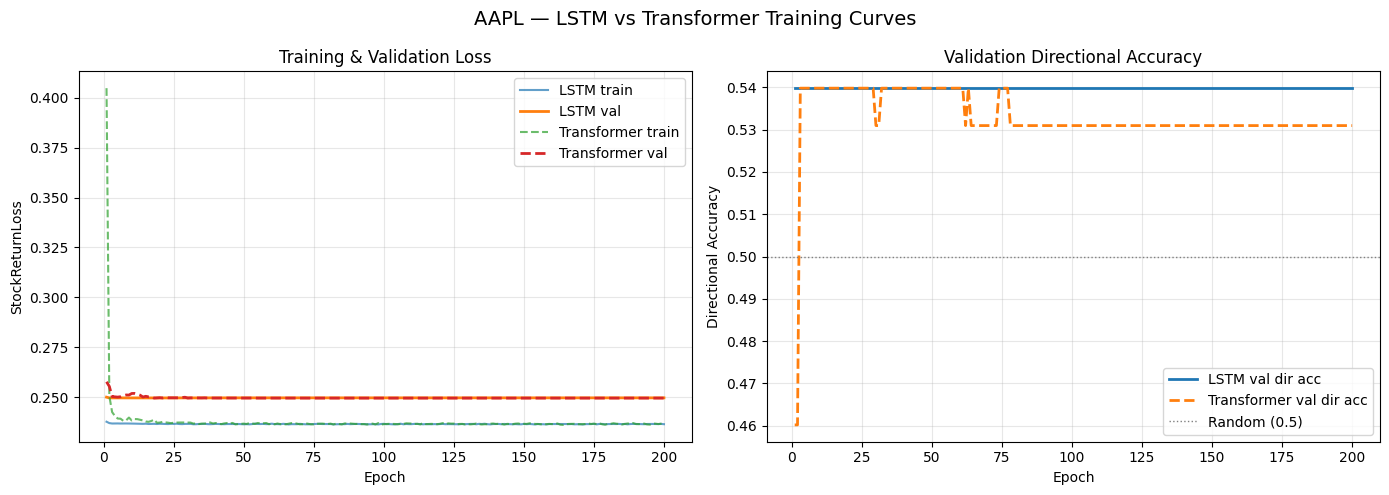

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = np.arange(1, len(lstm_history["val_loss"]) + 1)
tf_epochs = np.arange(1, len(tf_history["val_loss"]) + 1)

# --- Loss ---
ax = axes[0]
ax.plot(epochs,    lstm_history["train_loss"], label="LSTM train",        linewidth=1.5, alpha=0.7)
ax.plot(epochs,    lstm_history["val_loss"],   label="LSTM val",          linewidth=2)
ax.plot(tf_epochs, tf_history["train_loss"],   label="Transformer train", linewidth=1.5, alpha=0.7, linestyle="--")
ax.plot(tf_epochs, tf_history["val_loss"],     label="Transformer val",   linewidth=2,   linestyle="--")
ax.set_title("Training & Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("StockReturnLoss")
ax.legend()
ax.grid(True, alpha=0.3)

# --- Directional accuracy ---
ax = axes[1]
ax.plot(epochs,    lstm_history["val_dir"], label="LSTM val dir acc",        linewidth=2)
ax.plot(tf_epochs, tf_history["val_dir"],  label="Transformer val dir acc",  linewidth=2, linestyle="--")
ax.axhline(0.5, color="gray", linestyle=":", linewidth=1, label="Random (0.5)")
ax.set_title("Validation Directional Accuracy")
ax.set_xlabel("Epoch")
ax.set_ylabel("Directional Accuracy")
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle(f"{TICKER} — LSTM vs Transformer Training Curves", fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
# Optuna output placeholders — initialised here so the results cells work
# even if the Optuna cells are skipped entirely.
lstm_best_state = None
lstm_best_meta  = None
tf_best_state   = None
tf_best_meta    = None


## Optuna Hyperparameter Search

Run the two cells below to tune **LSTM** and **Transformer** independently.  
Each study runs `OPTUNA_N_TRIALS` trials of `OPTUNA_EPOCHS_PER_TRIAL` epochs each.

After the search, the best hyperparameters are printed and the best model weights
are stored in `lstm_best_state` / `tf_best_state` so the evaluation cells can use them directly.


In [ ]:
import optuna
from tqdm.auto import tqdm

optuna.logging.set_verbosity(optuna.logging.WARNING)

lstm_best_state  = None
lstm_best_meta   = None


def _lstm_objective(trial: optuna.Trial) -> float:
    use_vol   = trial.suggest_categorical("use_vol_features", [True, False])
    atr_span  = trial.suggest_int("atr_ewm_span", 7, 21) if use_vol else None
    rv_span   = trial.suggest_int("rv_ewm_span",  10, 40) if use_vol else None

    hidden    = trial.suggest_categorical("hidden_size", [32, 64, 128, 256])
    n_layers  = trial.suggest_int("num_layers", 1, 3)
    dropout   = trial.suggest_float("dropout",  0.0, 0.5)
    lr        = trial.suggest_float("learning_rate", 1e-4, 3e-3, log=True)
    wd        = trial.suggest_float("weight_decay",  1e-6, 1e-3, log=True)
    var_w     = trial.suggest_float("var_weight",  0.1, 5.0)
    dir_w     = trial.suggest_float("dir_weight",  0.05, 2.0)
    hinge_s   = trial.suggest_float("hinge_scale", 0.0, 1.0)

    input_dim = 5 + (NUM_VOL_FEATURES if use_vol else 0)
    p_t = prepare_datasets(df, lookback=LOOKBACK, horizon=HORIZON, batch_size=BATCH_SIZE,
                           use_vol_features=use_vol, atr_ewm_span=atr_span, rv_ewm_span=rv_span)
    tl = p_t["dataloaders"]["train"]
    vl = p_t["dataloaders"]["val"]

    m = LSTMForecaster(input_size=input_dim, hidden_size=hidden,
                       num_layers=n_layers, dropout=dropout).to(device)
    crit = StockReturnLoss(var_weight=var_w, dir_weight=dir_w, hinge_scale=hinge_s)
    opt  = optim.Adam(m.parameters(), lr=lr, weight_decay=wd)
    sched = optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode="min", patience=max(2, SCHEDULER_PATIENCE // 2),
        factor=SCHEDULER_FACTOR, min_lr=SCHEDULER_MIN_LR,
    )

    last_val_loss = float("inf")
    for _ in range(OPTUNA_EPOCHS_PER_TRIAL):
        m.train()
        for X, y in tl:
            X, y = X.to(device), y.to(device)
            opt.zero_grad(); crit(m(X), y).backward(); opt.step()
        m.eval()
        vl_loss = 0.0
        with torch.no_grad():
            for X, y in vl:
                X, y = X.to(device), y.to(device)
                vl_loss += crit(m(X), y).item() * X.size(0)
        last_val_loss = vl_loss / len(vl.dataset)
        sched.step(last_val_loss)

    # directional accuracy on val
    m.eval()
    ps, ts = [], []
    with torch.no_grad():
        for X, y in vl:
            ps.append(m(X.to(device)).cpu()); ts.append(y)
    val_dir = directional_accuracy(torch.cat(ps), torch.cat(ts))
    trial.set_user_attr("val_dir", float(val_dir) if val_dir == val_dir else float("nan"))

    trial.set_user_attr("_state", {k: v.detach().cpu().clone() for k, v in m.state_dict().items()})
    trial.set_user_attr("_meta",  {"input_dim": input_dim, "hidden_size": hidden,
                                    "num_layers": n_layers, "dropout": dropout,
                                    "use_vol_features": use_vol,
                                    "atr_ewm_span": atr_span, "rv_ewm_span": rv_span})

    if OPTUNA_OBJECTIVE == "val_directional_accuracy":
        return 1.0 - val_dir if val_dir == val_dir else 1.0
    return last_val_loss


lstm_study = optuna.create_study(direction="minimize",
                                  sampler=optuna.samplers.TPESampler(seed=OPTUNA_SEED))
pbar = tqdm(total=OPTUNA_N_TRIALS, desc="Optuna LSTM", unit="trial", dynamic_ncols=True)

def _lstm_cb(study, trial):
    pbar.update(1)
    if study.best_trial is not None:
        pbar.set_postfix(best_obj=f"{study.best_value:.4f}",
                         best_dir=f"{study.best_trial.user_attrs.get('val_dir', float('nan')):.4f}")

try:
    lstm_study.optimize(_lstm_objective, n_trials=OPTUNA_N_TRIALS,
                        show_progress_bar=False, callbacks=[_lstm_cb])
finally:
    pbar.close()

lstm_best_state = lstm_study.best_trial.user_attrs["_state"]
lstm_best_meta  = lstm_study.best_trial.user_attrs["_meta"]
print("\nLSTM best params:", lstm_study.best_params)
print(f"LSTM best val dir acc: {lstm_study.best_trial.user_attrs.get('val_dir', float('nan')):.4f}")


In [ ]:
tf_best_state = None
tf_best_meta  = None


def _tf_objective(trial: optuna.Trial) -> float:
    use_vol   = trial.suggest_categorical("use_vol_features", [True, False])
    atr_span  = trial.suggest_int("atr_ewm_span", 7, 21) if use_vol else None
    rv_span   = trial.suggest_int("rv_ewm_span",  10, 40) if use_vol else None

    d_model   = trial.suggest_categorical("d_model", [32, 64, 128])
    nhead     = trial.suggest_categorical("nhead", [2, 4])
    n_layers  = trial.suggest_int("num_layers", 1, 4)
    dropout   = trial.suggest_float("dropout", 0.05, 0.45)
    dim_ff    = trial.suggest_categorical("dim_feedforward", [128, 256, 512])
    lr        = trial.suggest_float("learning_rate", 1e-4, 3e-3, log=True)
    wd        = trial.suggest_float("weight_decay",  1e-6, 1e-3, log=True)
    var_w     = trial.suggest_float("var_weight",  0.1, 5.0)
    dir_w     = trial.suggest_float("dir_weight",  0.05, 2.0)
    hinge_s   = trial.suggest_float("hinge_scale", 0.0, 1.0)

    input_dim = 5 + (NUM_VOL_FEATURES if use_vol else 0)
    p_t = prepare_datasets(df, lookback=LOOKBACK, horizon=HORIZON, batch_size=BATCH_SIZE,
                           use_vol_features=use_vol, atr_ewm_span=atr_span, rv_ewm_span=rv_span)
    tl = p_t["dataloaders"]["train"]
    vl = p_t["dataloaders"]["val"]

    m = TimeSeriesTransformer(
        input_dim=input_dim, d_model=d_model, nhead=nhead, num_layers=n_layers,
        dropout=dropout, horizon=HORIZON, dim_feedforward=dim_ff,
        max_pos_len=TF_POS_ENCODING_MAX_LEN,
    ).to(device)
    crit  = StockReturnLoss(var_weight=var_w, dir_weight=dir_w, hinge_scale=hinge_s)
    opt   = optim.Adam(m.parameters(), lr=lr, weight_decay=wd)
    sched = optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode="min", patience=max(2, SCHEDULER_PATIENCE // 2),
        factor=SCHEDULER_FACTOR, min_lr=SCHEDULER_MIN_LR,
    )

    last_val_loss = float("inf")
    for _ in range(OPTUNA_EPOCHS_PER_TRIAL):
        m.train()
        for X, y in tl:
            X, y = X.to(device), y.to(device)
            opt.zero_grad(); crit(m(X), y).backward(); opt.step()
        m.eval()
        vl_loss = 0.0
        with torch.no_grad():
            for X, y in vl:
                X, y = X.to(device), y.to(device)
                vl_loss += crit(m(X), y).item() * X.size(0)
        last_val_loss = vl_loss / len(vl.dataset)
        sched.step(last_val_loss)

    m.eval()
    ps, ts = [], []
    with torch.no_grad():
        for X, y in vl:
            ps.append(m(X.to(device)).cpu()); ts.append(y)
    val_dir = directional_accuracy(torch.cat(ps), torch.cat(ts))
    trial.set_user_attr("val_dir", float(val_dir) if val_dir == val_dir else float("nan"))

    trial.set_user_attr("_state", {k: v.detach().cpu().clone() for k, v in m.state_dict().items()})
    trial.set_user_attr("_meta",  {"input_dim": input_dim, "d_model": d_model, "nhead": nhead,
                                    "num_layers": n_layers, "dropout": dropout, "horizon": HORIZON,
                                    "dim_feedforward": dim_ff, "max_pos_len": TF_POS_ENCODING_MAX_LEN,
                                    "use_vol_features": use_vol,
                                    "atr_ewm_span": atr_span, "rv_ewm_span": rv_span})

    if OPTUNA_OBJECTIVE == "val_directional_accuracy":
        return 1.0 - val_dir if val_dir == val_dir else 1.0
    return last_val_loss


tf_study = optuna.create_study(direction="minimize",
                                sampler=optuna.samplers.TPESampler(seed=OPTUNA_SEED))
pbar = tqdm(total=OPTUNA_N_TRIALS, desc="Optuna Transformer", unit="trial", dynamic_ncols=True)

def _tf_cb(study, trial):
    pbar.update(1)
    if study.best_trial is not None:
        pbar.set_postfix(best_obj=f"{study.best_value:.4f}",
                         best_dir=f"{study.best_trial.user_attrs.get('val_dir', float('nan')):.4f}")

try:
    tf_study.optimize(_tf_objective, n_trials=OPTUNA_N_TRIALS,
                      show_progress_bar=False, callbacks=[_tf_cb])
finally:
    pbar.close()

tf_best_state = tf_study.best_trial.user_attrs["_state"]
tf_best_meta  = tf_study.best_trial.user_attrs["_meta"]
print("\nTransformer best params:", tf_study.best_params)
print(f"Transformer best val dir acc: {tf_study.best_trial.user_attrs.get('val_dir', float('nan')):.4f}")


In [ ]:
# ── Evaluate best models on the test set ─────────────────────────────────────
#
# If the Optuna cells were run, the best trial weights are used automatically.
# If Optuna was skipped, this cell falls back to the manually trained models
# from the training cells above — no changes needed.

def get_test_preds(model, test_loader, device):
    """Collect all test predictions and targets as numpy arrays."""
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for X, y in test_loader:
            preds.append(model(X.to(device)).cpu())
            trues.append(y)
    return torch.cat(preds).numpy(), torch.cat(trues).numpy()


# ── LSTM: Optuna best or manual fallback ──────────────────────────────────────
if lstm_best_state is not None:
    _lm = lstm_best_meta
    _lstm_prepared = prepare_datasets(
        df, lookback=LOOKBACK, horizon=HORIZON, batch_size=BATCH_SIZE,
        use_vol_features=_lm["use_vol_features"],
        atr_ewm_span=_lm.get("atr_ewm_span"), rv_ewm_span=_lm.get("rv_ewm_span"),
    )
    best_lstm = LSTMForecaster(
        input_size=_lm["input_dim"], hidden_size=_lm["hidden_size"],
        num_layers=_lm["num_layers"], dropout=_lm["dropout"],
    ).to(device)
    best_lstm.load_state_dict(lstm_best_state)
    print("LSTM  : using Optuna best-trial weights.")
else:
    _lstm_prepared = prepared
    best_lstm = lstm_model
    print("LSTM  : Optuna not run — using manually trained model.")

# ── Transformer: Optuna best or manual fallback ───────────────────────────────
if tf_best_state is not None:
    _tm = tf_best_meta
    _tf_prepared = prepare_datasets(
        df, lookback=LOOKBACK, horizon=HORIZON, batch_size=BATCH_SIZE,
        use_vol_features=_tm["use_vol_features"],
        atr_ewm_span=_tm.get("atr_ewm_span"), rv_ewm_span=_tm.get("rv_ewm_span"),
    )
    best_tf = TimeSeriesTransformer(
        input_dim=_tm["input_dim"], d_model=_tm["d_model"], nhead=_tm["nhead"],
        num_layers=_tm["num_layers"], dropout=_tm["dropout"], horizon=_tm["horizon"],
        dim_feedforward=_tm["dim_feedforward"], max_pos_len=_tm["max_pos_len"],
    ).to(device)
    best_tf.load_state_dict(tf_best_state)
    print("Trans : using Optuna best-trial weights.")
else:
    _tf_prepared = prepared
    best_tf = tf_model
    print("Trans : Optuna not run — using manually trained model.")

# ── Run test inference ────────────────────────────────────────────────────────
lstm_preds, lstm_true = get_test_preds(best_lstm, _lstm_prepared["dataloaders"]["test"], device)
tf_preds,   tf_true   = get_test_preds(best_tf,   _tf_prepared["dataloaders"]["test"],   device)

actual_returns = lstm_true.reshape(-1)
lstm_pred_rets = lstm_preds.reshape(-1)
tf_pred_rets   = tf_preds.reshape(-1)

lstm_dir = directional_accuracy(torch.tensor(lstm_pred_rets), torch.tensor(actual_returns))
tf_dir   = directional_accuracy(torch.tensor(tf_pred_rets),   torch.tensor(actual_returns))

print(f"\nTest directional accuracy — LSTM: {lstm_dir:.4f}  |  Transformer: {tf_dir:.4f}")


## Results: Percent Returns & Reconstructed Price

In [11]:
# ── Graph 1: Predicted vs Actual percent returns (full test set) ──────────────
n_test = len(actual_returns)
x = np.arange(n_test)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(x, actual_returns,  label="Actual close return",      linewidth=1.8, color="steelblue")
ax.plot(x, lstm_pred_rets,  label="LSTM predicted return",    linewidth=1.2, alpha=0.85, color="darkorange", linestyle="--")
ax.plot(x, tf_pred_rets,    label="Transformer predicted return", linewidth=1.2, alpha=0.85, color="forestgreen", linestyle="-.")
ax.axhline(0, color="black", linewidth=0.8, linestyle=":")
ax.set_title(f"{TICKER} — Test Set: Predicted vs Actual Percent Returns\n"
             f"LSTM dir acc: {lstm_dir:.3f}  |  Transformer dir acc: {tf_dir:.3f}")
ax.set_xlabel("Test window index")
ax.set_ylabel("Close return (fraction)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


NameError: name 'actual_returns' is not defined

In [ ]:
# ── Graph 2: Reconstructed raw price from percent returns ─────────────────────
#
# Strategy: starting from each day's *last known* close, reconstruct the next
# predicted close as:  predicted_close[t] = close[t-1] * (1 + predicted_return[t])
#
# We need the close prices aligned with the test windows.
# The test window starts at returns_df index (val_end - LOOKBACK).
# returns_df.iloc[i] corresponds to df.iloc[i + 1] because pct_change drops row 0.
# So test target at position k in the test set corresponds to df close at:
#   df.iloc[ (val_end - LOOKBACK) + LOOKBACK + k + 1 ]  = df.iloc[ val_end + k + 1 ]

returns_df_plot = prepared["returns_df"]
n_returns       = len(returns_df_plot)
val_end_idx     = int(n_returns * VAL_END_FRAC)

# Index of df row for each test target
# (returns_df has one fewer row than df due to pct_change; offset by 1)
first_test_df_idx = val_end_idx + 1   # first close target row in df

n_plot = min(len(actual_returns), len(df) - first_test_df_idx - 1)

actual_closes   = df["close"].iloc[first_test_df_idx : first_test_df_idx + n_plot].values
prev_closes     = df["close"].iloc[first_test_df_idx - 1 : first_test_df_idx - 1 + n_plot].values

lstm_pred_closes = prev_closes * (1.0 + lstm_pred_rets[:n_plot])
tf_pred_closes   = prev_closes * (1.0 + tf_pred_rets[:n_plot])

x_price = np.arange(n_plot)

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# --- top: all three series ---
ax = axes[0]
ax.plot(x_price, actual_closes,    label="Actual close",             linewidth=2,   color="steelblue")
ax.plot(x_price, lstm_pred_closes, label="LSTM predicted close",     linewidth=1.5, color="darkorange",  linestyle="--", alpha=0.85)
ax.plot(x_price, tf_pred_closes,   label="Transformer predicted close", linewidth=1.5, color="forestgreen", linestyle="-.", alpha=0.85)
ax.set_title(f"{TICKER} — Test Set: Reconstructed Close Price")
ax.set_ylabel("Close Price (USD)")
ax.legend()
ax.grid(True, alpha=0.3)

# --- bottom: prediction errors ---
ax = axes[1]
ax.plot(x_price, lstm_pred_closes - actual_closes, label="LSTM error",        color="darkorange",  linewidth=1.2)
ax.plot(x_price, tf_pred_closes   - actual_closes, label="Transformer error",  color="forestgreen", linewidth=1.2, linestyle="--")
ax.axhline(0, color="black", linewidth=0.8, linestyle=":")
ax.set_title("Prediction Error (predicted − actual)")
ax.set_xlabel("Test window index")
ax.set_ylabel("Error (USD)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── Summary stats ──────────────────────────────────────────────────────────────
lstm_mae  = np.mean(np.abs(lstm_pred_closes - actual_closes))
tf_mae    = np.mean(np.abs(tf_pred_closes   - actual_closes))
lstm_rmse = np.sqrt(np.mean((lstm_pred_closes - actual_closes) ** 2))
tf_rmse   = np.sqrt(np.mean((tf_pred_closes   - actual_closes) ** 2))

print(f"\nPrice-level metrics (test set, n={n_plot})")
print(f"{'':20s}  {'MAE':>8}  {'RMSE':>8}  {'Dir Acc':>8}")
print(f"{'LSTM':20s}  {lstm_mae:8.4f}  {lstm_rmse:8.4f}  {lstm_dir:8.4f}")
print(f"{'Transformer':20s}  {tf_mae:8.4f}  {tf_rmse:8.4f}  {tf_dir:8.4f}")


In [ ]:
# ── Single-sample close-price forecast (SAMPLE_IDX into test set) ─────────────
test_dataset = prepared["dataloaders"]["test"].dataset

single_X, single_y = test_dataset[SAMPLE_IDX]
single_X_dev = single_X.unsqueeze(0).to(device)

with torch.no_grad():
    lstm_ret_sample = lstm_model(single_X_dev).cpu().numpy().flatten()
    tf_ret_sample   = tf_model(single_X_dev).cpu().numpy().flatten()

actual_ret_sample = single_y.numpy().flatten()

# Reconstruct prices
sample_df_idx = first_test_df_idx + SAMPLE_IDX
last_known_close = df["close"].iloc[sample_df_idx - 1]
actual_next      = df["close"].iloc[sample_df_idx : sample_df_idx + HORIZON].values

lstm_price_sample = last_known_close * np.cumprod(1 + lstm_ret_sample)
tf_price_sample   = last_known_close * np.cumprod(1 + tf_ret_sample)
actual_price_cump = last_known_close * np.cumprod(1 + actual_ret_sample)

history_close = df["close"].iloc[sample_df_idx - LOOKBACK : sample_df_idx].values
hist_x  = np.arange(LOOKBACK)
fut_x   = np.arange(LOOKBACK - 1, LOOKBACK - 1 + HORIZON)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9))

# --- top: price ---
ax1.plot(hist_x, history_close,     marker="o", linewidth=2,   label="Historical close")
ax1.plot(fut_x,  actual_next,       marker="o", linewidth=2,   label="Actual future close")
ax1.plot(fut_x,  lstm_price_sample, marker="s", linewidth=2,   label="LSTM forecast",        linestyle="--", color="darkorange")
ax1.plot(fut_x,  tf_price_sample,   marker="^", linewidth=2,   label="Transformer forecast", linestyle="-.", color="forestgreen")
ax1.axvline(x=LOOKBACK - 1, linestyle=":", alpha=0.5)
ax1.set_title(f"Sample {SAMPLE_IDX} — {LOOKBACK}-day window + {HORIZON}-day forecast")
ax1.set_xlabel("Time step")
ax1.set_ylabel("Close Price (USD)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- bottom: returns bar chart ---
ret_x = np.arange(HORIZON)
width = 0.25
ax2.bar(ret_x - width, actual_ret_sample, width=width, label="Actual return",       alpha=0.85)
ax2.bar(ret_x,         lstm_ret_sample,   width=width, label="LSTM return",         alpha=0.85, color="darkorange")
ax2.bar(ret_x + width, tf_ret_sample,     width=width, label="Transformer return",  alpha=0.85, color="forestgreen")
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_title("Percent Returns: Model Outputs")
ax2.set_xlabel("Forecast step")
ax2.set_ylabel("Return (fraction)")
ax2.set_xticks(ret_x)
ax2.set_xticklabels([f"t+{i+1}" for i in ret_x])
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
